In [3]:
# Deep learning models - MvTec Anamoly detection
# Anamoly detection for category Transistor
# Predict labels -  0 for good images and 1 for defective images
# Binary Classification

import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

# Importation pour la transformation sur les images
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomBrightness
from tensorflow.keras.layers import RandomContrast
from tensorflow.keras.layers import RandomTranslation 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Importation de l'utilitaire image_dataset_from_directory de Keras
from keras.utils import image_dataset_from_directory
#from tensorflow.keras.applications import VGG16
#from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
import tensorflow as tf
from tensorflow.keras import layers, models

# Importation pour les visualisations
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.metrics import classification_report_imbalanced

from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from collections import Counter

C:\Users\kavit\miniconda3\envs\env_test\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [32]:
df = pd.read_pickle("Data/mvtec_full_images_colour.pkl")
print(df.shape)
#df.head()

df_category = df[df["category_name"] == 'transistor']
display(df_category)

(5346, 7)


,file_path,category_name,dir_name,file_name,file_size,label,img
4317,..\Projects\mvtec_anomaly_detection\transistor...,transistor,bent_lead,000.png,1296700,1,"[[[133, 91, 86], [147, 102, 96], [148, 105, 97..."
4318,..\Projects\mvtec_anomaly_detection\transistor...,transistor,bent_lead,001.png,1285834,1,"[[[140, 97, 92], [141, 101, 93], [145, 102, 93..."
4319,..\Projects\mvtec_anomaly_detection\transistor...,transistor,bent_lead,002.png,1287496,1,"[[[147, 105, 92], [149, 103, 91], [135, 93, 86..."
4320,..\Projects\mvtec_anomaly_detection\transistor...,transistor,bent_lead,003.png,1274214,1,"[[[147, 101, 91], [147, 104, 91], [152, 104, 9..."
4321,..\Projects\mvtec_anomaly_detection\transistor...,transistor,bent_lead,004.png,1284517,1,"[[[162, 117, 108], [161, 117, 109], [161, 115,..."
...,...,...,...,...,...,...,...
4624,..\Projects\mvtec_anomaly_detection\transistor...,transistor,good,208.png,1274771,0,"[[[154, 106, 94], [157, 107, 95], [162, 109, 9..."
4625,..\Projects\mvtec_anomaly_detection\transistor...,transistor,good,209.png,1276350,0,"[[[146, 103, 90], [145, 103, 91], [151, 106, 9..."
4626,..\Projects\mvtec_anomaly_detection\transistor...,transistor,good,210.png,1282411,0,"[[[147, 103, 94], [148, 104, 91], [149, 105, 9..."
4627,..\Projects\mvtec_anomaly_detection\transistor...,transistor,good,211.png,1294543,0,"[[[151, 103, 89], [149, 103, 90], [150, 104, 8..."


In [33]:
# Get X and y
# Stack images
X = np.stack(df_category['img']).astype(np.float32)

# Preprocess for MobileNetV2
#X = preprocess_input(X)
y = df_category['label'].values

print(Counter(y))


Counter({np.int64(0): 273, np.int64(1): 39})


In [34]:
#Split data
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

In [35]:
Counter(y_train)

Counter({np.int64(0): 191, np.int64(1): 27})

In [36]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

X_train = preprocess_input(X_train)
X_val   = preprocess_input(X_val)
X_test  = preprocess_input(X_test)

In [37]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator()

train_gen = train_datagen.flow(X_train, y_train, batch_size=8, shuffle=True)
val_gen   = val_datagen.flow(X_val, y_val, batch_size=8, shuffle=False)


In [38]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {0: class_weights[0], 1: class_weights[1]}
print(class_weights)

{0: np.float64(0.5706806282722513), 1: np.float64(4.037037037037037)}


In [39]:
# Use Pre-trained model for anamoly detection with new classifier

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(256, 256, 3)
)

base.trainable = False

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(base.input, output)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

C:\Users\kavit\AppData\Local\Temp\ipykernel_5764\600694907.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(


In [40]:
# Train the model with class weights for class imbalance
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weights
    #callbacks=[early_stopping, reduce_learning_rate ]
)

model.save('Models/model_predict_label_MobileNet_1_with_Classweights.keras')

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 368ms/step - accuracy: 0.4450 - loss: 1.3548 - precision: 0.1017 - recall: 0.4444 - val_accuracy: 0.8723 - val_loss: 0.4438 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 279ms/step - accuracy: 0.5688 - loss: 0.7391 - precision: 0.1398 - recall: 0.4815 - val_accuracy: 0.6809 - val_loss: 0.6226 - val_precision: 0.2632 - val_recall: 0.8333
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 281ms/step - accuracy: 0.8486 - loss: 0.5848 - precision: 0.4211 - recall: 0.5926 - val_accuracy: 0.3617 - val_loss: 0.8035 - val_precision: 0.1667 - val_recall: 1.0000
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 282ms/step - accuracy: 0.6835 - loss: 0.5787 - precision: 0.2500 - recall: 0.7778 - val_accuracy: 0.2766 - val_loss: 0.9803 - val_precision: 0.1500 - val_recall: 1.0000
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 283ms/step - accuracy: 0.7798 - loss: 0.5150 - precision: 0.3333 - recall: 0.7778 - val_accuracy: 0.6596 - val

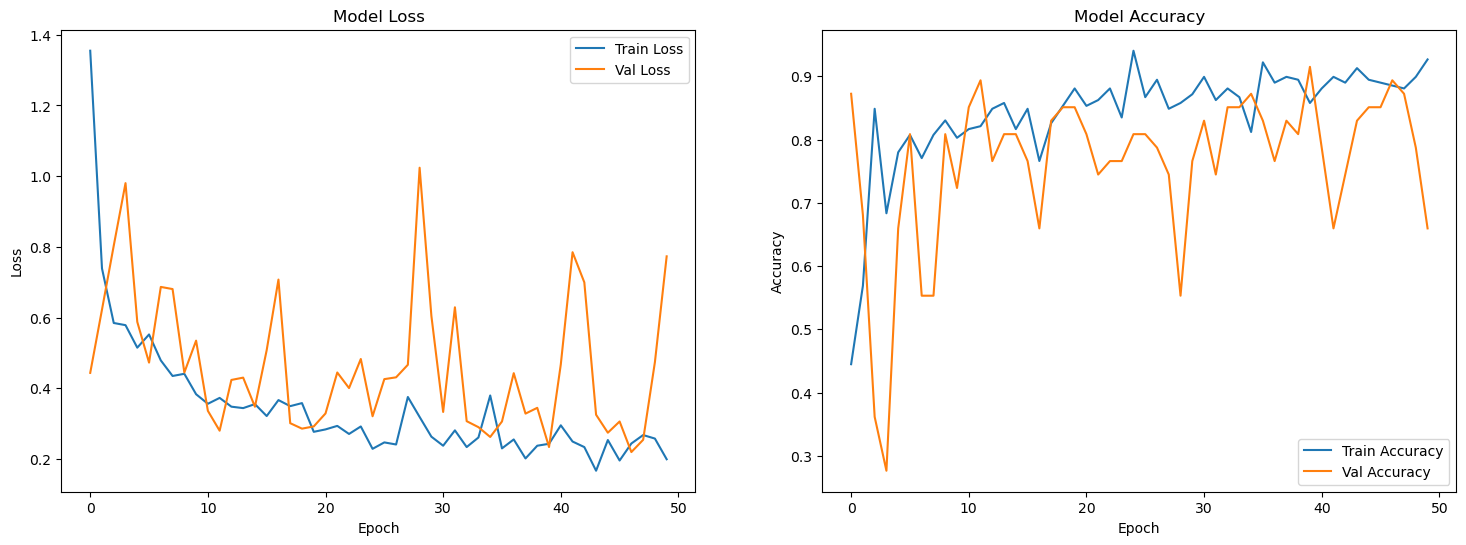

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step
              precision    recall  f1-score   support

           0       1.00      0.59      0.74        41
           1       0.26      1.00      0.41         6

    accuracy                           0.64        47
   macro avg       0.63      0.79      0.58        47
weighted avg       0.91      0.64      0.70        47

Validation Accuracy: 0.6383


Text(0.5, 1.0, 'Validation Confusion Matrix')

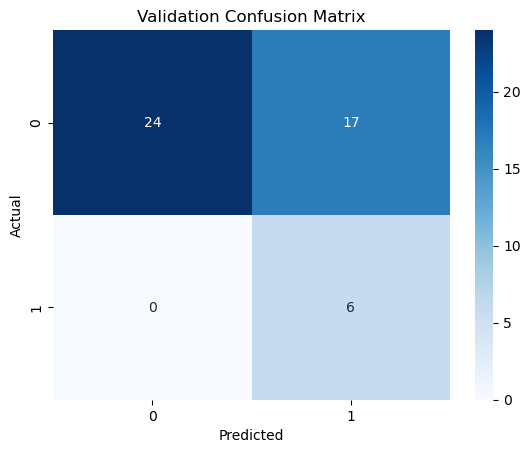

In [41]:
# Train the model with class weights for class imbalance
# Accuracy and loss graphes converges and close to each other which means the model generalizes well and able to learn the pattern

# model_predict_label_MobileNet_1_with_Classweights (Graph is correct, for confusion matrix, see next bloc)
#loaded_model = load_model('Models/model_predict_label_MobileNet_1_with_Classweights.keras')

# Anamoly detection 
display_loss_accuracy_graph(history)
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred, zero_division=0))

val_acc = accuracy_score(y_test, y_pred)
print(f"Validation Accuracy: {val_acc:.4f}")

val_cm = confusion_matrix(y_test, y_pred)

sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Confusion Matrix")

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step
              precision    recall  f1-score   support

           0       1.00      0.61      0.76        41
           1       0.27      1.00      0.43         6

    accuracy                           0.66        47
   macro avg       0.64      0.80      0.59        47
weighted avg       0.91      0.66      0.72        47

Validation Accuracy: 0.6596


Text(0.5, 1.0, 'Validation Confusion Matrix')

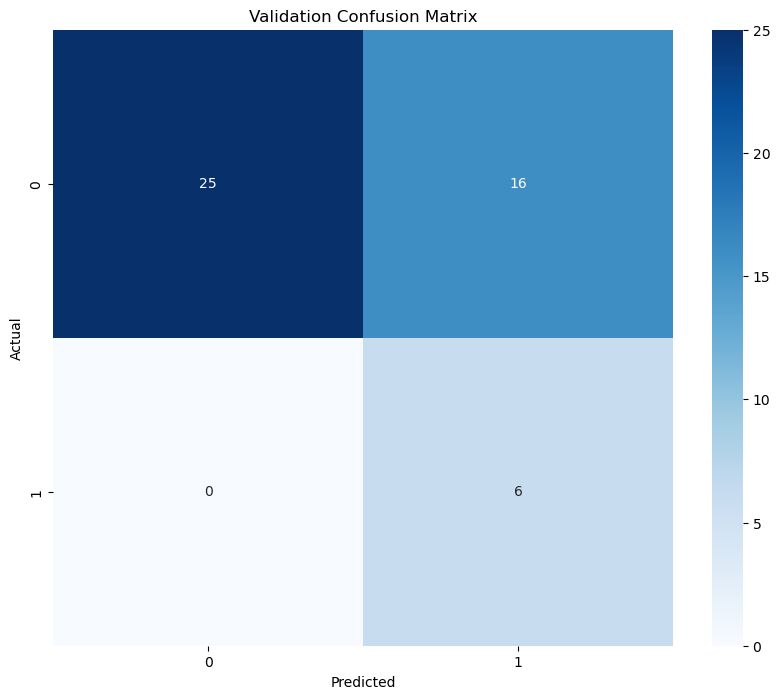

In [19]:
# model_predict_label_MobileNet_1_with_Classweights - Confusion matrix
loaded_model = load_model('Models/model_predict_label_MobileNet_1_with_Classweights.keras')

y_prob = loaded_model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred, zero_division=0))

val_acc = accuracy_score(y_test, y_pred)
print(f"Validation Accuracy: {val_acc:.4f}")

val_cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Confusion Matrix")

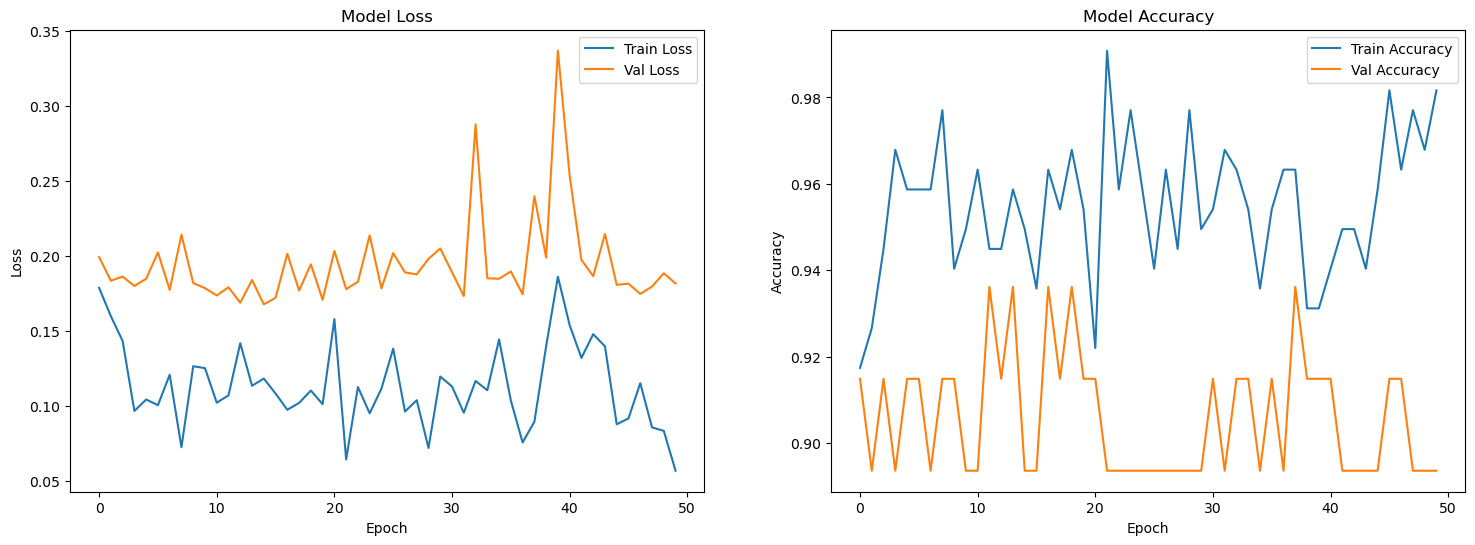

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 333ms/step
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        41
           1       0.80      0.67      0.73         6

    accuracy                           0.94        47
   macro avg       0.88      0.82      0.85        47
weighted avg       0.93      0.94      0.93        47

Validation Accuracy: 0.9362


Text(0.5, 1.0, 'Validation Confusion Matrix')

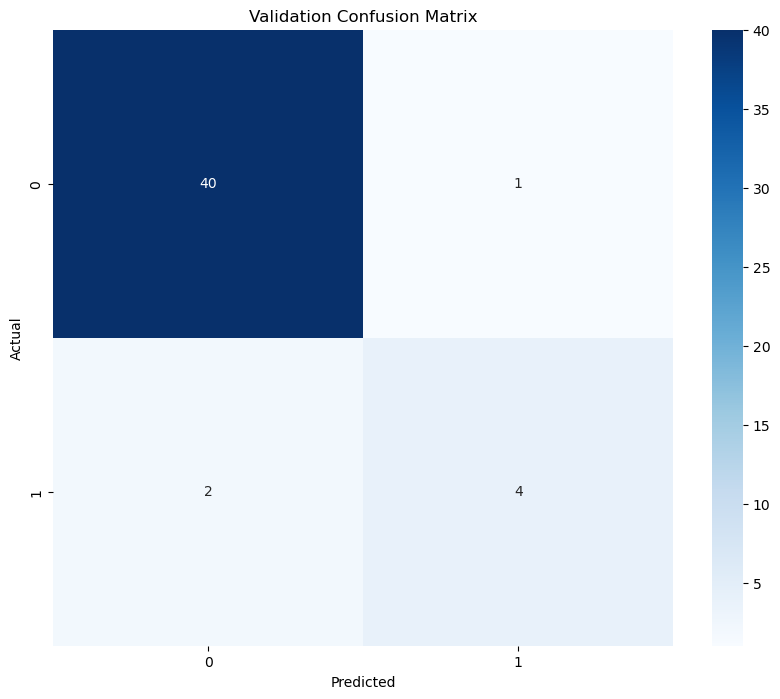

In [43]:
# Train the model without class weights for class imbalance
# Accuracy and loss graphes of train and validation data have gap between them which means that the model is not generalizing well
# Confusion matrix shows wrong predictions of model

# model_predict_label_MobileNet_1_without_Classweights
#loaded_model = load_model('Models/model_predict_label_MobileNet_1_without_Classweights.keras')

display_loss_accuracy_graph(history)
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred, zero_division=0))

val_acc = accuracy_score(y_test, y_pred)
print(f"Validation Accuracy: {val_acc:.4f}")

val_cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Confusion Matrix")

In [17]:
# Loss and Accuracy graphs of train and validation data from model training history

def display_loss_accuracy_graph(model_history):
    train_loss = model_history.history["loss"]
    val_loss = model_history.history["val_loss"]
    train_acc = model_history.history["accuracy"]
    val_acc = model_history.history["val_accuracy"]

    plt.figure(figsize=(18,6))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(train_loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.title("Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Val Accuracy')
    plt.title("Model Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()


In [42]:
# Anamoly detection with MobileNet convlution base layers unfreezed to improve the model performance
#Predict labels -  0 for good imahges and 1 for defective images

base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(256, 256, 3)
)

base.trainable = True
for layer in base.layers[:-20]:
    layer.trainable = False

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(base.input, output)


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)


history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights

)

model.save('Models/model_predict_label_MobileNet_1_Unfreezed_layers.keras')

C:\Users\kavit\AppData\Local\Temp\ipykernel_5764\3764397588.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(


Epoch 1/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 24s 418ms/step - accuracy: 0.5367 - loss: 0.7076 - precision: 0.1224 - recall: 0.4444 - val_accuracy: 0.1064 - val_loss: 1.0005 - val_precision: 0.1087 - val_recall: 0.8333
Epoch 2/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 344ms/step - accuracy: 0.5734 - loss: 0.6817 - precision: 0.1071 - recall: 0.3333 - val_accuracy: 0.1064 - val_loss: 0.9570 - val_precision: 0.1087 - val_recall: 0.8333
Epoch 3/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 356ms/step - accuracy: 0.6789 - loss: 0.6394 - precision: 0.2133 - recall: 0.5926 - val_accuracy: 0.1277 - val_loss: 0.9393 - val_precision: 0.1277 - val_recall: 1.0000
Epoch 4/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 310ms/step - accuracy: 0.7615 - loss: 0.5979 - precision: 0.3016 - recall: 0.7037 - val_accuracy: 0.1489 - val_loss: 0.9157 - val_precision: 0.1304 - val_recall: 1.0000
Epoch 5/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 326ms/step - accuracy: 0.7477 - loss: 0.5885 - precision: 0.2812 - recall: 0.6667 - val_accuracy: 0.2128 - val_loss:

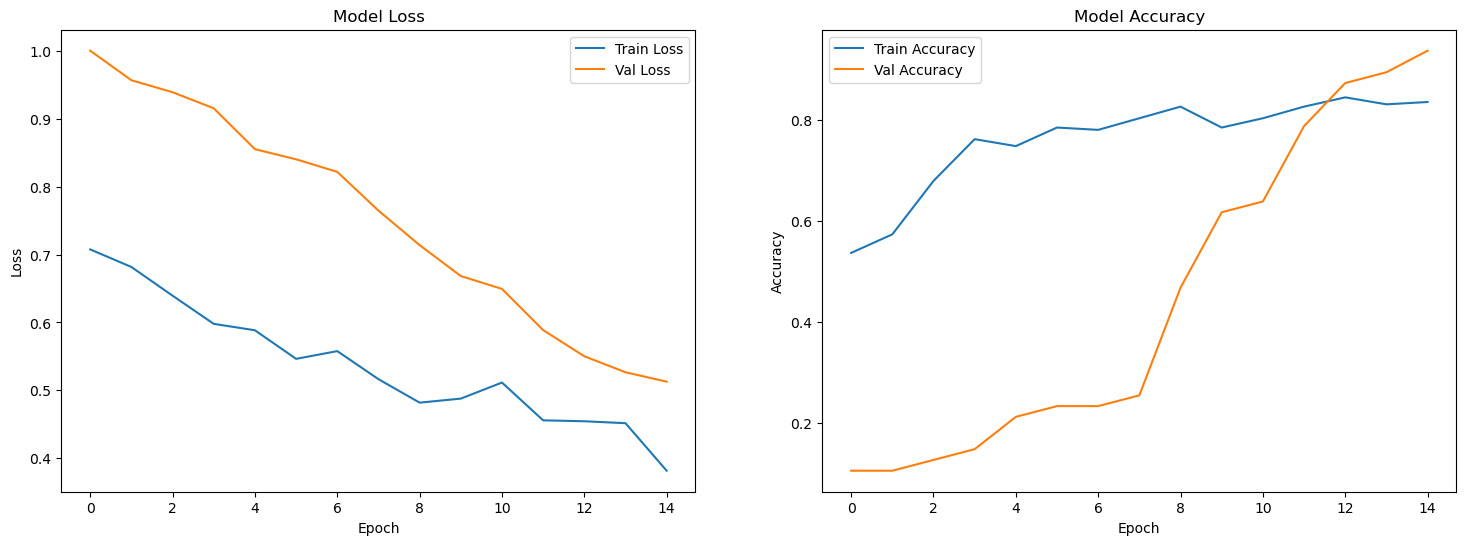

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 359ms/step
              precision    recall  f1-score   support

           0       0.97      0.88      0.92        41
           1       0.50      0.83      0.62         6

    accuracy                           0.87        47
   macro avg       0.74      0.86      0.77        47
weighted avg       0.91      0.87      0.89        47

Validation Accuracy: 0.8723


Text(0.5, 1.0, 'Validation Confusion Matrix')

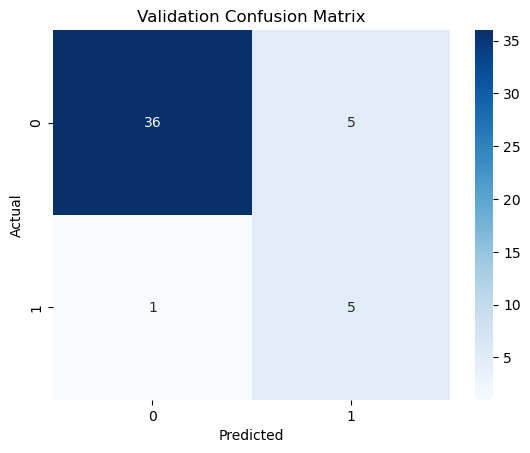

In [44]:

display_loss_accuracy_graph(history)
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred, zero_division=0))

val_acc = accuracy_score(y_test, y_pred)
print(f"Validation Accuracy: {val_acc:.4f}")

val_cm = confusion_matrix(y_test, y_pred)

sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Confusion Matrix")

In [92]:
# Maximize Recall with controlled False Positives

y_prob = model.predict(X_val).ravel()  # probabilities for class = defective
y_true = y_val

import numpy as np
from sklearn.metrics import confusion_matrix

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    recall = tp / (tp + fn + 1e-9)
    fpr = fp / (fp + tn + 1e-9)

    results.append((t, recall, fpr))

best = [r for r in results if r[1] >= 0.9]
best_threshold = min(best, key=lambda x: x[2])

print("Best threshold:", best_threshold)



2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 241ms/step
Best threshold: (np.float64(0.5000000000000001), np.float64(0.9999999998333333), np.float64(0.170731707312909))


In [93]:
THRESHOLD = best_threshold[0]  # from method 1

y_test_prob = model.predict(X_test).ravel()
y_test_pred = (y_test_prob >= THRESHOLD).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred, zero_division=0))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        41
           1       0.50      1.00      0.67         6

    accuracy                           0.87        47
   macro avg       0.75      0.93      0.79        47
weighted avg       0.94      0.87      0.89        47



In [45]:
# Grad-CAM - Interpretability of prediction results

last_conv_layer_name = "Conv_1"
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]  # defective class (sigmoid)

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()
def overlay_gradcam(original_img, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed = heatmap * alpha + original_img

    return np.uint8(superimposed)


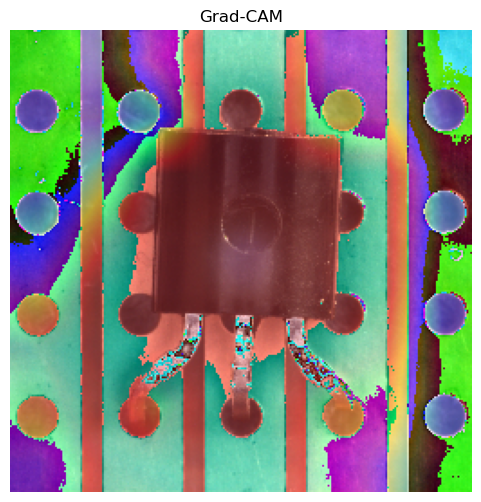

In [47]:
idx = 1  # index from X_test
img = X_test[idx]
#img = preprocess_input(img)
img_input = np.expand_dims(img, axis=0)
heatmap = make_gradcam_heatmap(
    img_input,
    model,
    last_conv_layer_name
)
superimposed_img = overlay_gradcam(
    (img * 255).astype(np.uint8),  # de-normalize if needed
    heatmap
)

plt.figure(figsize=(6,6))

plt.imshow(superimposed_img)
plt.axis("off")
plt.title("Grad-CAM")
plt.show()

In [109]:
import numpy as np

false_positive_indices = np.where(
    (y_test == 0) & (y_test_pred == 1)
)[0]

print(f"False positives found: {len(false_positive_indices)}")


False positives found: 6


In [110]:
import tensorflow as tf

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]  # defective class

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-9)
    return heatmap.numpy()


In [111]:
import cv2

def overlay_gradcam(original_img, heatmap, alpha=0.4):
    heatmap = cv2.resize(
        heatmap,
        (original_img.shape[1], original_img.shape[0])
    )

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = cv2.addWeighted(
        original_img, 1 - alpha,
        heatmap, alpha,
        0
    )
    return superimposed


In [115]:
import os

def denormalize_mobilenet_img(img):
    """
    Convert preprocessed MobileNetV2 image [-1,1] -> uint8 [0,255]
    """
    img = (img + 1.0) * 127.5  # [-1,1] -> [0,255]
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

SAVE_DIR = "C:/Kavitha/DataScientest/Projects/gradcam_outputs/transistor/gradcam_false_positives"
os.makedirs(SAVE_DIR, exist_ok=True)

last_conv_layer_name = "Conv_1"  # MobileNetV2

for idx in false_positive_indices:
    # Preprocessed input
    img_input = np.expand_dims(X_test[idx], axis=0)

    # Original image for visualization
    original_img = denormalize_mobilenet_img(X_test[idx])

    # Grad-CAM
    heatmap = make_gradcam_heatmap(
        img_input,
        model,
        last_conv_layer_name
    )

    cam_img = overlay_gradcam(original_img, heatmap)

    # Save
    save_path = os.path.join(SAVE_DIR, f"fp_{idx}.png")
    cv2.imwrite(save_path, cv2.cvtColor(cam_img, cv2.COLOR_RGB2BGR))


In [116]:
import numpy as np

true_negative_indices = np.where(
    (y_test == 1) & (y_test_pred == 1)
)[0]

print(f"True negative found: {len(true_negative_indices)}")


True negative found: 6


In [117]:
import os

SAVE_DIR = "C:/Kavitha/DataScientest/Projects/gradcam_outputs/transistor/gradcam_true_negatives"
os.makedirs(SAVE_DIR, exist_ok=True)

last_conv_layer_name = "Conv_1"  # MobileNetV2

for idx in true_negative_indices:
    # Preprocessed input
    img_input = np.expand_dims(X_test[idx], axis=0)

    # Original image for visualization
    original_img = denormalize_mobilenet_img(X_test[idx])

    # Grad-CAM
    heatmap = make_gradcam_heatmap(
        img_input,
        model,
        last_conv_layer_name
    )

    cam_img = overlay_gradcam(original_img, heatmap)

    # Save
    save_path = os.path.join(SAVE_DIR, f"fp_{idx}.png")
    cv2.imwrite(save_path, cv2.cvtColor(cam_img, cv2.COLOR_RGB2BGR))


In [119]:
import numpy as np

true_positive_indices = np.where(
    (y_test == 0) & (y_test_pred == 0)
)[0]

print(f"True positive found: {len(true_positive_indices)}")


True positive found: 35


In [120]:
import os

SAVE_DIR = "C:/Kavitha/DataScientest/Projects/gradcam_outputs/transistor/gradcam_true_positives"
os.makedirs(SAVE_DIR, exist_ok=True)

last_conv_layer_name = "Conv_1"  # MobileNetV2

for idx in true_positive_indices:
    # Preprocessed input
    img_input = np.expand_dims(X_test[idx], axis=0)

    # Original image for visualization
    original_img = denormalize_mobilenet_img(X_test[idx])

    # Grad-CAM
    heatmap = make_gradcam_heatmap(
        img_input,
        model,
        last_conv_layer_name
    )

    cam_img = overlay_gradcam(original_img, heatmap)

    # Save
    save_path = os.path.join(SAVE_DIR, f"fp_{idx}.png")
    cv2.imwrite(save_path, cv2.cvtColor(cam_img, cv2.COLOR_RGB2BGR))